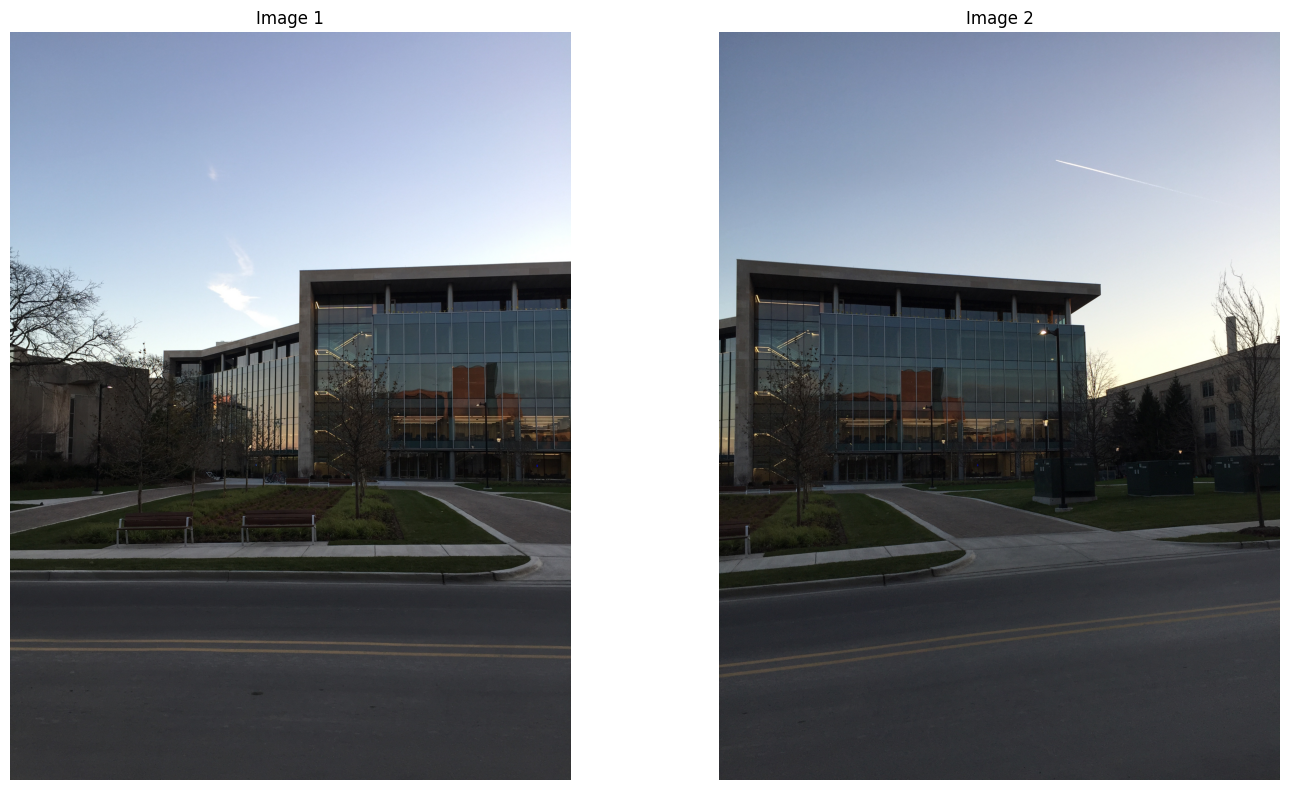

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os

def load_images(image_paths):
    """Load multiple images from paths"""
    images = []
    for path in image_paths:
        img = cv2.imread(path)
        if img is None:
            raise ValueError(f"Could not load image: {path}")
        images.append(img)
    return images

# Example usage - replace with your image paths
image_paths = ['image-3.jpg','image-4.jpg']
images = load_images(image_paths)

# Display input images
plt.figure(figsize=(15, 8))
for i, img in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Image {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

### **Registration**

Number of good matches: 1515
Homography matrix computed successfully.


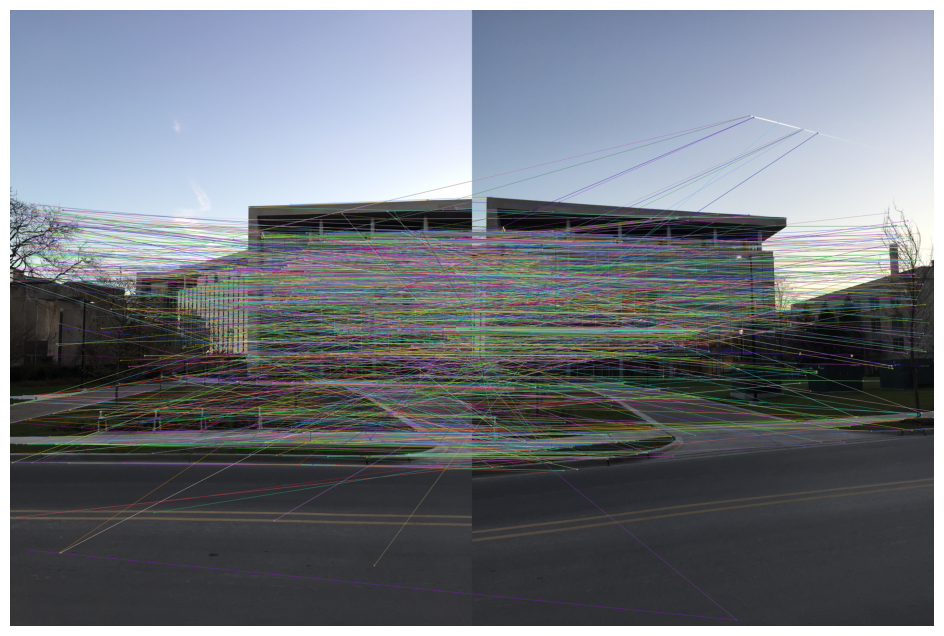

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def registration(img1, img2, ratio=0.85, min_match=10):
    sift = cv2.SIFT_create()
    
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    matcher = cv2.BFMatcher()
    raw_matches = matcher.knnMatch(des1, des2, k=2)
    
    good_points = []
    good_matches = []
    
    for m1, m2 in raw_matches:
        if m1.distance < ratio * m2.distance:
            good_points.append((m1.trainIdx, m1.queryIdx))
            good_matches.append([m1])
    
    img3 = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good_matches, None, flags=2)
    
    # Convert the BGR image to RGB for display
    img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

    print(f"Number of good matches: {len(good_matches)}")
    
    if len(good_points) > min_match:
        image1_kp = np.float32([kp1[i].pt for (_, i) in good_points])
        image2_kp = np.float32([kp2[i].pt for (i, _) in good_points])
        H, status = cv2.findHomography(image2_kp, image1_kp, cv2.RANSAC, 5.0)
        print("Homography matrix computed successfully.")
        return H, img3_rgb
    else:
        print("Not enough good matches found.")
        return None

# Example usage
img1 = cv2.imread('image-3.jpg')  # Provide the path to the first image
img2 = cv2.imread('image-4.jpg')  # Provide the path to the second image

# Run registration function
H, img = registration(img1, img2)

# Show the matching keypoints image using plt.imshow
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

### **Create Masking**

In [5]:
def create_mask(img1, img2, version, smoothing_window_size=800):
    height_img1 = img1.shape[0]
    width_img1 = img1.shape[1]
    width_img2 = img2.shape[1]
    height_panorama = height_img1
    width_panorama = width_img1 + width_img2
    
    offset = int(smoothing_window_size / 2)
    barrier = img1.shape[1] - offset
    mask = np.zeros((height_panorama, width_panorama))
    
    if version == 'left_image':
        mask[:, barrier - offset:barrier + offset] = np.tile(np.linspace(1, 0, 2 * offset).T, (height_panorama, 1))
        mask[:, :barrier - offset] = 1
    else:
        mask[:, barrier - offset:barrier + offset] = np.tile(np.linspace(0, 1, 2 * offset).T, (height_panorama, 1))
        mask[:, barrier + offset:] = 1
    
    return cv2.merge([mask, mask, mask])

# Run create_mask for left image
mask1 = create_mask(img1, img2, version='left_image')

# Show the mask
print(f"Mask1 shape: {mask1.shape}")


Mask1 shape: (3264, 4896, 3)


### **Image Blending**

Number of good matches: 1515
Homography matrix computed successfully.


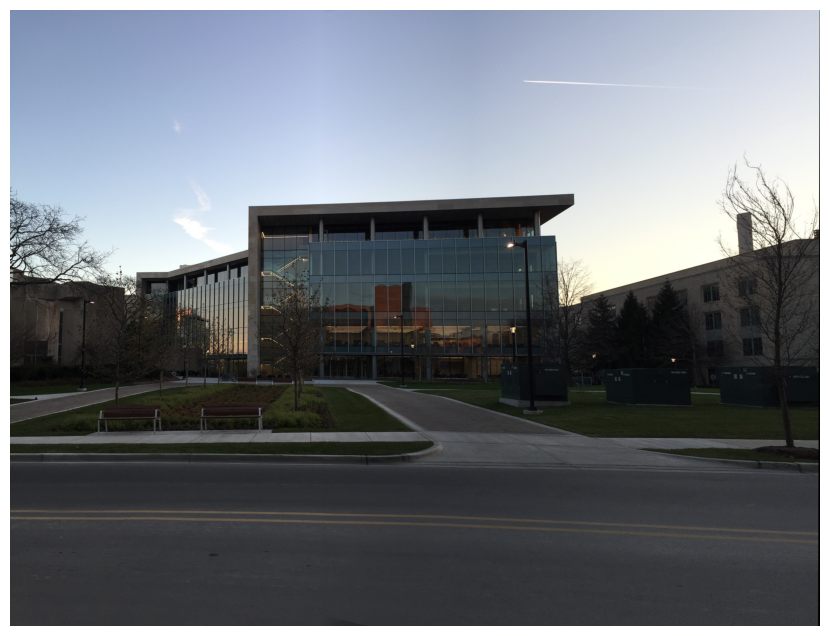

Panorama displayed.


In [6]:
def blending(img1, img2, ratio=0.85, min_match=10, smoothing_window_size=800):
    H, _ = registration(img1, img2, ratio, min_match)
    height_img1 = img1.shape[0]
    width_img1 = img1.shape[1]
    width_img2 = img2.shape[1]
    height_panorama = height_img1
    width_panorama = width_img1 + width_img2

    panorama1 = np.zeros((height_panorama, width_panorama, 3))
    mask1 = create_mask(img1, img2, version='left_image', smoothing_window_size=smoothing_window_size)
    panorama1[0:img1.shape[0], 0:img1.shape[1], :] = img1
    panorama1 *= mask1
    
    mask2 = create_mask(img1, img2, version='right_image', smoothing_window_size=smoothing_window_size)
    panorama2 = cv2.warpPerspective(img2, H, (width_panorama, height_panorama)) * mask2
    result = panorama1 + panorama2

    rows, cols = np.where(result[:, :, 0] != 0)
    min_row, max_row = min(rows), max(rows) + 1
    min_col, max_col = min(cols), max(cols) + 1
    final_result = result[min_row:max_row, min_col:max_col, :]
    
    return final_result

import matplotlib.pyplot as plt

# Run blending function
final_result = blending(img1, img2)

# Show the result using matplotlib
if final_result is not None:
    # Convert from float64 to uint8
    final_result_uint8 = np.uint8(final_result)

    # Convert BGR image to RGB
    final_result_rgb = cv2.cvtColor(final_result_uint8, cv2.COLOR_BGR2RGB)
    
    # Display the final panorama using plt.show()
    plt.figure(figsize=(12, 8))
    plt.imshow(final_result_rgb)
    plt.axis('off')  # Hide axes
    plt.show()

    print("Panorama displayed.")
else:
    print("Blending was not successful.")


### **Using Builtin**

Stitching successful.


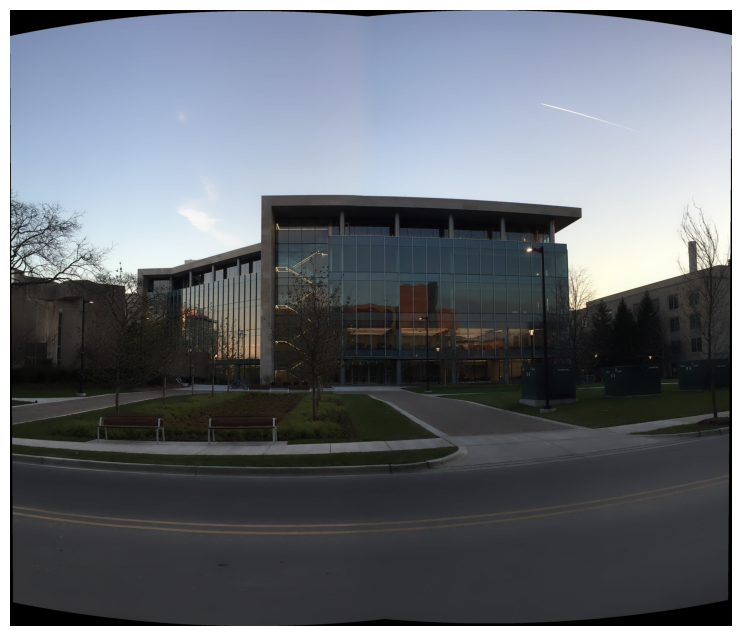

In [3]:
import cv2
import matplotlib.pyplot as plt

def stitch_images_builtin(img1, img2):
    # Initialize OpenCV's stitcher
    stitcher = cv2.Stitcher_create()
    
    # Stitch the images
    status, stitched = stitcher.stitch([img1, img2])
    
    if status == cv2.Stitcher_OK:
        print("Stitching successful.")
        # Convert the BGR stitched image to RGB for display
        stitched_rgb = cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB)
        return stitched_rgb
    else:
        print(f"Stitching failed with status code {status}.")
        return None

# Example usage
img1 = cv2.imread('image-3.jpg')  # Provide the path to the first image
img2 = cv2.imread('image-4.jpg')  # Provide the path to the second image

# Run the built-in stitching function
stitched_image = stitch_images_builtin(img1, img2)

# Show the stitched image using plt.imshow
if stitched_image is not None:
    plt.figure(figsize=(12, 8))
    plt.imshow(stitched_image)
    plt.axis('off')  # Hide axes
    plt.show()
